# K-Nearest Neighbors (KNN) for CICIDS-2017 Dataset
This notebook provides a robust replication of the `KNN_final.py` script, with optimized SHAP analysis for performance.

In [1]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, accuracy_score
from collections import Counter
from sklearn.preprocessing import label_binarize
import time
import matplotlib.pyplot as plt
import shap
import os

np.random.seed(0)

## Defining Features of Interest
We use the 15 features identified as most significant in the research.

In [2]:
req_cols = [
    ' Packet Length Std', ' Total Length of Bwd Packets', ' Subflow Bwd Bytes',
    ' Destination Port', ' Packet Length Variance', ' Bwd Packet Length Mean',
    ' Avg Bwd Segment Size', 'Bwd Packet Length Max', ' Init_Win_bytes_backward',
    'Total Length of Fwd Packets', ' Subflow Fwd Bytes', 'Init_Win_bytes_forward',
    ' Average Packet Size', ' Packet Length Mean', ' Max Packet Length', ' Label'
]

## Loading Database

In [3]:
db_path = '../cicids_db/'
files = [
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv'
]

frames = []
for f in files:
    path = os.path.join(db_path, f)
    print(f'Loading {f}...')
    df_tmp = pd.read_csv(path, usecols=req_cols, low_memory=False, encoding='cp1252')
    frames.append(df_tmp)

df = pd.concat(frames, ignore_index=True)
# Using 10% sample fraction for KNN as per original script
df = df.sample(frac=0.1, random_state=0)
print("Finished loading all databases.")

Loading Wednesday-workingHours.pcap_ISCX.csv...
Loading Tuesday-WorkingHours.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv...
Loading Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv...
Loading Monday-WorkingHours.pcap_ISCX.csv...
Loading Friday-WorkingHours-Morning.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv...
Loading Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv...
Finished loading all databases.


## Preprocessing (Normalization and Label Grouping)
We clean the column names, handle label replacements, and perform max normalization.

In [4]:
# Normalize column names (remove leading spaces)
df.columns = df.columns.str.strip()

# Filter out header rows if they appear in concat
df = df[df['Label'] != 'Label']

# Label replacement
y = df['Label'].replace({
    'DoS GoldenEye': 'Dos/Ddos', 'DoS Hulk': 'Dos/Ddos', 'DoS Slowhttptest': 'Dos/Ddos',
    'DoS slowloris': 'Dos/Ddos', 'Heartbleed': 'Dos/Ddos', 'DDoS': 'Dos/Ddos',
    'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
    'Web Attack - Brute Force': 'Web Attack', 'Web Attack - Sql Injection': 'Web Attack', 'Web Attack - XSS': 'Web Attack',
    'Web Attack XSS': 'Web Attack', 'Web Attack Sql Injection': 'Web Attack', 'Web Attack Brute Force': 'Web Attack'
})

# Ensure numeric features
X = df.drop(columns=['Label'])
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors='coerce')

# Max Normalization
for col in X.columns:
    m = abs(X[col].max())
    if m != 0:
        X[col] = X[col] / m

df = X.assign(Label = y)

# Robustly fill NaNs: Numeric with 0, Label with BENIGN
for col in df.columns:
    if col == 'Label':
        df[col] = df[col].fillna('BENIGN').astype(str)
    else:
        df[col] = df[col].fillna(0)

print("Preprocessing complete.")

Preprocessing complete.


## Separating Training and Testing db
We use the specific 70-30 split logic.

In [5]:
df['is_train'] = np.random.uniform(0, 1, len(df)) <= .70
train, test = df[df['is_train']==True], df[df['is_train']==False]
print('Number of the training data:', len(train))
print('Number of the testing data:', len(test))

features = X.columns
y_train, label = pd.factorize(train['Label'])
y_test = test['Label'].map({name: i for i, name in enumerate(label)}).fillna(0).astype(int)

X_train = np.array(train[features])
X_test = np.array(test[features])
print("Training labels:", label)

Number of the training data: 218426
Number of the testing data: 93508
Training labels: Index(['Dos/Ddos', 'BENIGN', 'PortScan', 'Brute Force', 'Web Attack – XSS',
       'Bot', 'Web Attack – Brute Force'],
      dtype='object')


## Model Construction
Hyperparameters: Default KNN.

In [6]:
knn = KNeighborsClassifier()
start = time.time()
model = knn.fit(X_train, y_train)
print(f"ELAPSE TIME MODEL: {(time.time() - start)/60:.2f} min")

ELAPSE TIME MODEL: 0.01 min


## Evaluation Metrics

In [7]:
y_pred = model.predict(X_test)
pred_label = label[y_pred]

# Ensure all labels are strings to avoid sorting issues
actual_series = test['Label'].astype(str)
pred_series = pd.Series(pred_label, index=test.index).astype(str)

conf_matrix = pd.crosstab(actual_series, pred_series, rownames=['Actual ALERT'], colnames=['Predicted ALERT']).sort_index(axis=0).sort_index(axis=1)
print(conf_matrix)

print('Accuracy:', metrics.accuracy_score(y_test, y_pred))
y_score = knn.predict_proba(X_test)
y_test_bin = label_binarize(y_test, classes=range(len(label)))
if y_test_bin.shape[1] > 1:
    print('ROC-AUC:', roc_auc_score(y_test_bin, y_score, multi_class='ovr'))

Predicted ALERT           BENIGN  Bot  Brute Force  Dos/Ddos  PortScan  \
Actual ALERT                                                             
BENIGN                     76533   10            5        60       270   
Bot                           30   33            0         0         0   
Brute Force                    3    0          430         0         0   
Dos/Ddos                      27    0            0     11329         0   
Infiltration                   2    0            0         0         0   
PortScan                      12    0            0         6      4699   
Web Attack – Brute Force      35    0            0         0         0   
Web Attack – XSS              17    0            0         0         0   

Predicted ALERT           Web Attack – Brute Force  
Actual ALERT                                        
BENIGN                                           4  
Bot                                              0  
Brute Force                                    

## SHAP Analysis
Calculating SHAP values for 20 samples using a 10-sample representative background. This is optimized for speed on KNN.

Calculating SHAP values for 20 samples...


  0%|          | 0/20 [00:00<?, ?it/s]

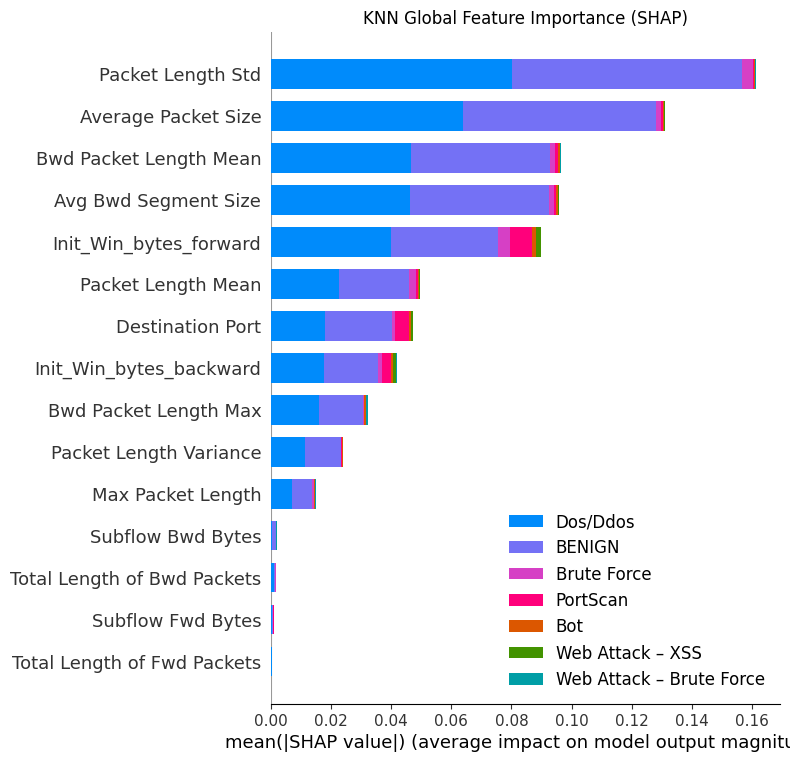

In [8]:
import warnings
warnings.filterwarnings('ignore')

start_index = 0
end_index = 20
test_data_for_shap = test[features].iloc[start_index:end_index]

print(f"Calculating SHAP values for {end_index} samples...")
# Optimization: Using a small background sample (10) from training data to speed up KernelExplainer
background_data = shap.sample(X_train, 10)

explainer = shap.KernelExplainer(knn.predict_proba, background_data)
shap_values = explainer.shap_values(test_data_for_shap.values)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, test_data_for_shap, class_names=label.tolist(), show=False, plot_type='bar')
plt.title("KNN Global Feature Importance (SHAP)")
plt.savefig('KNN_Shap_Summary_global.png', bbox_inches='tight')
plt.show()